In [1]:
import pickle
import pandas as pd
import os

In [2]:
train_landmarks = []
test_landmarks = []



# Load train landmarks
with open('train_landmarks.pkl', 'rb') as f:
    train_landmarks = pickle.load(f)

# Load test landmarks
with open('test_landmarks.pkl', 'rb') as f:
    test_landmarks = pickle.load(f)

# Optionally, print to verify
print("Train Landmarks Loaded:", len(train_landmarks))
print("Test Landmarks Loaded:", len(test_landmarks))

Train Landmarks Loaded: 105
Test Landmarks Loaded: 28


In [3]:

# Load labels
train_labels = pd.read_csv('ASL_TRAIN.csv', header=0)
test_labels = pd.read_csv('ASL_TEST.csv', header=0)

In [4]:
import torch
from torch.nn.utils.rnn import pack_padded_sequence, pad_sequence
from torch.utils.data import Dataset, DataLoader
import numpy as np

class SignLanguageDataset(Dataset):
    def __init__(self, landmarks_dict, labels_df):
        valid_entries = []
        for _, row in labels_df.iterrows():
            video_name = row['video_name']
            class_name = row['class_name']
            if video_name in landmarks_dict:
                landmarks = landmarks_dict[video_name]
                if landmarks and len(landmarks) > 0 and np.array(landmarks).shape[1] == 225:
                    valid_entries.append((video_name, class_name))
                else:
                    print(f"Skipping {video_name}: Invalid landmarks {np.array(landmarks).shape}")
        self.valid_data = valid_entries
        self.landmarks_dict = landmarks_dict
        self.class_to_idx = {cls: idx for idx, cls in enumerate(labels_df['class_name'].unique())}

    def __len__(self):
        return len(self.valid_data)

    def __getitem__(self, idx):
        video_name, class_name = self.valid_data[idx]
        label = self.class_to_idx[class_name]
        landmarks = self.landmarks_dict[video_name]
        landmarks_tensor = torch.tensor(landmarks, dtype=torch.float32)
        if landmarks_tensor.shape[0] == 0 or landmarks_tensor.shape[1] != 225:
            raise ValueError(f"Invalid landmarks shape for {video_name}: {landmarks_tensor.shape}")
        return landmarks_tensor, label

def collate_fn(batch):
    landmarks, labels = zip(*batch)
    lengths = [len(l) for l in landmarks]
    padded_landmarks = pad_sequence(landmarks, batch_first=True)
    packed_landmarks = pack_padded_sequence(padded_landmarks, lengths, batch_first=True, enforce_sorted=False)
    return packed_landmarks, torch.tensor(labels)

In [5]:
import numpy as np
import random
from scipy.interpolate import interp1d

def augment_landmarks_dict(landmarks_dict, augment_count=1):
    """
    Augments the landmark data in the given dictionary.

    Args:
        landmarks_dict (dict): {filename: list of landmark frames}
        augment_count (int): Number of augmented versions per sample

    Returns:
        dict: Original and augmented landmark data
    """
    augmented_landmarks_dict = {}
    for filename, landmarks in landmarks_dict.items():
        augmented_landmarks_dict[filename] = landmarks  # Keep original
        
        # Convert to numpy array and ensure 2D shape
        landmarks_np = np.array(landmarks)
        if landmarks_np.ndim != 2 or landmarks_np.shape[0] == 0:
            print(f"Skipping {filename}: Invalid shape {landmarks_np.shape}")
            continue
        
        for i in range(augment_count):
            augmented_filename = f"augmented_{i+1}_{filename}"
            augmented_landmarks = augment_sequence(landmarks_np)
            augmented_landmarks_dict[augmented_filename] = augmented_landmarks.tolist()
    return augmented_landmarks_dict

def augment_sequence(landmarks):
    augmented = landmarks.copy()
    augmented = temporal_warp(augmented, warp_factor_range=(0.8, 1.2))  # Wider range
    augmented = add_noise(augmented, std=0.01)  # More noise
    augmented = keypoint_jitter(augmented, max_jitter=0.02)  # More jitter
    return augmented

def temporal_warp(landmarks, warp_factor_range=(0.9, 1.1)):
    """Performs temporal warping by interpolating."""
    num_frames = landmarks.shape[0]
    time_points = np.arange(num_frames)
    warp_factor = random.uniform(warp_factor_range[0], warp_factor_range[1])
    new_num_frames = max(1, int(num_frames * warp_factor))  # Ensure at least 1 frame
    
    new_time_points = np.linspace(0, num_frames - 1, new_num_frames)
    augmented_landmarks = np.zeros((new_num_frames, landmarks.shape[1]))
    for i in range(landmarks.shape[1]):
        f = interp1d(time_points, landmarks[:, i], kind='linear', fill_value="extrapolate")
        augmented_landmarks[:, i] = f(new_time_points)
    return augmented_landmarks

def add_noise(landmarks, std=0.005):
    """Adds Gaussian noise to landmarks."""
    noise = np.random.normal(0, std, landmarks.shape)
    return landmarks + noise

def keypoint_jitter(landmarks, max_jitter=0.01):
    """Randomly jitters landmark positions."""
    jitter = np.random.uniform(-max_jitter, max_jitter, landmarks.shape)
    return landmarks + jitter

# Assuming train_labels is your DataFrame from the CSV
def get_label_from_filename(filename, labels_df):
    # Remove the augmentation prefix if present
    if filename.startswith("augmented_"):
        original_filename = "_".join(filename.split("_")[2:])
    else:
        original_filename = filename
    row = labels_df[labels_df['video_name'] == original_filename]
    if not row.empty:
        return row['class_name'].iloc[0]
    return None

def add_augmented_labels(labels_df, augmented_landmarks_dict):
    """
    Adds labels for augmented data to the labels DataFrame.

    Args:
        labels_df (pd.DataFrame): The original labels DataFrame.
        augmented_landmarks_dict (dict): The dictionary of augmented landmarks.

    Returns:
        pd.DataFrame: A new DataFrame with added labels for augmented data.
    """
    new_rows = []
    for filename in augmented_landmarks_dict.keys():
        if filename not in labels_df['video_name'].values:  # Check if it's an augmented file
            parts = filename.split('_', 2)  # Split by the first two underscores (e.g., "augmented_1_video.mp4")
            if len(parts) == 3 and parts[0] == "augmented":
                original_filename = parts[2]
                original_label_row = labels_df[labels_df['video_name'] == original_filename]
                if not original_label_row.empty:
                    new_row = original_label_row.iloc[0].copy()  # Copy the original label row
                    new_row['video_name'] = filename  # Update the filename to the augmented one
                    new_rows.append(new_row)

    augmented_labels_df = pd.concat([labels_df, pd.DataFrame(new_rows)], ignore_index=True)
    return augmented_labels_df

In [6]:
# Augumenting
train_landmarks = augment_landmarks_dict(train_landmarks, augment_count=10)
test_landmarks = augment_landmarks_dict(test_landmarks, augment_count=4)

Skipping why_3_515_5_523.mp4: Invalid shape (0,)
Skipping why_0_502_3_013.mp4: Invalid shape (0,)
Skipping eat_9_04_12_52.mp4: Invalid shape (0,)
Skipping why_158_291_160_727.mp4: Invalid shape (0,)


In [7]:
# Add labels for augmented data
train_labels = add_augmented_labels(train_labels, train_landmarks)
test_labels = add_augmented_labels(test_labels, test_landmarks)

# After augmentation
train_labels = train_labels[train_labels['video_name'].isin(train_landmarks.keys())]
test_labels = test_labels[test_labels['video_name'].isin(test_landmarks.keys())]

train_dataset = SignLanguageDataset(train_landmarks, train_labels)
test_dataset = SignLanguageDataset(test_landmarks, test_labels)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

Skipping eat_9_04_12_52.mp4: Invalid landmarks (0,)
Skipping why_3_515_5_523.mp4: Invalid landmarks (0,)
Skipping why_0_502_3_013.mp4: Invalid landmarks (0,)
Skipping why_158_291_160_727.mp4: Invalid landmarks (0,)


In [8]:
print(train_labels.columns)


Index(['#', 'video_name', 'class_name'], dtype='object')


In [9]:
# Check if data is loading correctly
for landmarks, label in train_loader:
    # Access the underlying data of the PackedSequence
    landmarks_data = landmarks.data
    print(f"Landmarks shape: {landmarks_data.shape}, Label: {label}")
    break


Landmarks shape: torch.Size([2450, 225]), Label: tensor([2, 3, 1, 1, 0, 0, 3, 0, 0, 2, 3, 1, 1, 3, 3, 3, 3, 0, 2, 0, 2, 3, 3, 0,
        2, 2, 3, 3, 0, 0, 0, 2])


In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimplerSignLanguageLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, dropout_rate=0.3):
        super(SimplerSignLanguageLSTM, self).__init__()

        # Input regularization
        self.input_dropout = nn.Dropout(0.3)
        self.input_bn = nn.BatchNorm1d(input_size)

        # Single Bidirectional LSTM layer with reduced size
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True,
                            dropout=dropout_rate, bidirectional=True)

        # Smaller fully connected layers
        self.fc1 = nn.Linear(hidden_size * 2, 64)
        self.fc2 = nn.Linear(64, num_classes)

        # Moderate dropout
        self.dropout = nn.Dropout(dropout_rate)

        # Weight initialization
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.LSTM):
            for name, param in module.named_parameters():
                if 'weight_ih' in name:
                    nn.init.xavier_uniform_(param.data)
                elif 'weight_hh' in name:
                    nn.init.orthogonal_(param.data)
                elif 'bias' in name:
                    nn.init.zeros_(param.data)

    def forward(self, packed_input):
        # Unpack input for batch normalization
        padded_input, lengths = nn.utils.rnn.pad_packed_sequence(packed_input, batch_first=True)

        # Apply input normalization and dropout
        padded_input = padded_input.transpose(1, 2)
        padded_input = self.input_bn(padded_input)
        padded_input = padded_input.transpose(1, 2)
        padded_input = self.input_dropout(padded_input)

        # Repack input
        packed_input = nn.utils.rnn.pack_padded_sequence(
            padded_input, lengths, batch_first=True, enforce_sorted=False
        )

        # Single LSTM layer
        packed_output, (h_n, c_n) = self.lstm(packed_input)

        # Concatenate the final hidden states
        output_forward = h_n[0, :, :]
        output_backward = h_n[1, :, :]
        output = torch.cat((output_forward, output_backward), dim=1)

        # Fully connected layers
        output = self.fc1(output)
        output = F.relu(output)
        output = self.dropout(output)
        output = self.fc2(output)

        return output

# Training configuration tailored for small datasets
def get_training_config():
    return {
        'hidden_size': 128, 
        'learning_rate': 1e-3,
        'num_epochs': 300,
        'weight_decay': 1e-4,
        'dropout_rate': 0.3,
        'scheduler_params': {
            'factor': 0.5,
            'min_lr': 1e-6
        },
    }

In [11]:
import torch.optim as optim

# Initialize the improved model
config = get_training_config()
model = SimplerSignLanguageLSTM(
    input_size=225,  # Updated from 1629 to 225
    hidden_size=config['hidden_size'],
    num_classes=len(train_labels['class_name'].unique().tolist()),
    dropout_rate=config['dropout_rate']
)

# Modified optimizer setup
optimizer = optim.AdamW(
    model.parameters(),
    lr=config['learning_rate'],
    weight_decay=config['weight_decay']
)

# Modified scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    **config['scheduler_params']
)

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/rnn.py:88: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


In [12]:
# Check if CUDA is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move the model to the appropriate device
model.to(device)
device

device(type='cpu')

In [13]:
import torch
import torch.nn as nn
from tqdm import tqdm

# EarlyStopping class to monitor validation accuracy
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0, restore_best_weights=True):
        """
        Args:
            patience (int): How many epochs to wait for improvement before stopping.
            min_delta (float): Minimum change in validation accuracy to qualify as improvement.
            restore_best_weights (bool): Whether to restore model weights from the best epoch.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.counter = 0
        self.best_accuracy = None
        self.early_stop = False
        self.best_weights = None

    def __call__(self, accuracy, model):
        if self.best_accuracy is None:
            self.best_accuracy = accuracy
            self.best_weights = model.state_dict()
        elif accuracy > self.best_accuracy + self.min_delta:
            self.best_accuracy = accuracy
            self.best_weights = model.state_dict()
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
                if self.restore_best_weights:
                    model.load_state_dict(self.best_weights)
                print(f"Early stopping triggered after {self.counter} epochs without improvement.")

# HParams
num_epochs = config['num_epochs'] 
lr = config['learning_rate'] 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Loss and optimization functions
criterion = nn.CrossEntropyLoss()
best_accuracy = 0.0

# Define class names (ensure this matches your labels)
class_names = ['eat', 'meat', 'you', 'why']  # Update based on train_labels['class_name'].unique().tolist()

# Initialize early stopping
early_stopping = EarlyStopping(patience=10, min_delta=0.01)  # Stop if no 1% improvement after 10 epochs

training_history = []

for epoch in range(num_epochs):
    if early_stopping.early_stop:
        print(f"Training stopped early at epoch {epoch}")
        break
    
    # Training phase
    model.train()
    running_loss = 0.0
    
    # Use tqdm for progress bar
    train_pbar = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs} [Train]')
    for landmarks, labels in train_pbar:
        landmarks, labels = landmarks.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(landmarks)
        loss = criterion(outputs, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        
        running_loss += loss.item()
        train_pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_train_loss = running_loss / len(train_loader)
    
    # Evaluation phase
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        val_pbar = tqdm(test_loader, desc=f'Epoch {epoch + 1}/{num_epochs} [Valid]')
        for landmarks, labels in val_pbar:
            landmarks, labels = landmarks.to(device), labels.to(device)
            outputs = model(landmarks)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            val_pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    accuracy = correct / total
    avg_val_loss = val_loss / len(test_loader)
    
    # Update learning rate based on validation accuracy
    scheduler.step(accuracy)
    
    print(f"""Epoch {epoch + 1}/{num_epochs}
Training loss: {avg_train_loss:.4f}
Validation loss: {avg_val_loss:.4f}
Accuracy: {accuracy * 100:.2f}%
Current LR: {optimizer.param_groups[0]['lr']:.2e}
""")

    # Store training history
    training_history.append({
        'epoch': epoch + 1,
        'train_loss': avg_train_loss,
        'val_loss': avg_val_loss,
        'acc': accuracy,
        'lr': optimizer.param_groups[0]['lr']
    })
    
    # Check early stopping
    early_stopping(accuracy, model)
    
    # Save best model with class names
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'accuracy': accuracy,
            'class_names': class_names,  # Save class names (plural) for reference
        }, 'best_model.pth')
        print(f'Saved new best model with accuracy: {best_accuracy:.2f}\n-----')

# Final message if early stopping occurred
if early_stopping.early_stop:
    print(f"Final best validation accuracy: {early_stopping.best_accuracy * 100:.2f}%")
else:
    print(f"Completed all {num_epochs} epochs. Best validation accuracy: {best_accuracy * 100:.2f}%")

Using device: cpu


Epoch 1/300 [Valid]: 100%|██████████| 5/5 [00:00<00:00, 11.87it/s, loss=1.2768]


Epoch 1/300
Training loss: 1.0814
Validation loss: 1.4979
Accuracy: 34.07%
Current LR: 1.00e-03

Saved new best model with accuracy: 0.34
-----


Epoch 2/300 [Valid]: 100%|██████████| 5/5 [00:00<00:00, 11.90it/s, loss=0.6398]


Epoch 2/300
Training loss: 0.5431
Validation loss: 1.0422
Accuracy: 51.11%
Current LR: 1.00e-03

Saved new best model with accuracy: 0.51
-----


...

Epoch 27/300
Training loss: 0.0010
Validation loss: 1.2525
Accuracy: 80.74%
Current LR: 1.00e-03



Epoch 28/300 [Valid]: 100%|██████████| 5/5 [00:00<00:00, 12.30it/s, loss=1.2583]


Epoch 28/300
Training loss: 0.0079
Validation loss: 1.2357
Accuracy: 77.78%
Current LR: 1.00e-03



Epoch 29/300 [Valid]: 100%|██████████| 5/5 [00:00<00:00, 11.23it/s, loss=0.0001]

Epoch 29/300
Training loss: 0.0055
Validation loss: 1.1801
Accuracy: 81.48%
Current LR: 1.00e-03

Early stopping triggered after 10 epochs without improvement.
Training stopped early at epoch 29
Final best validation accuracy: 85.93%


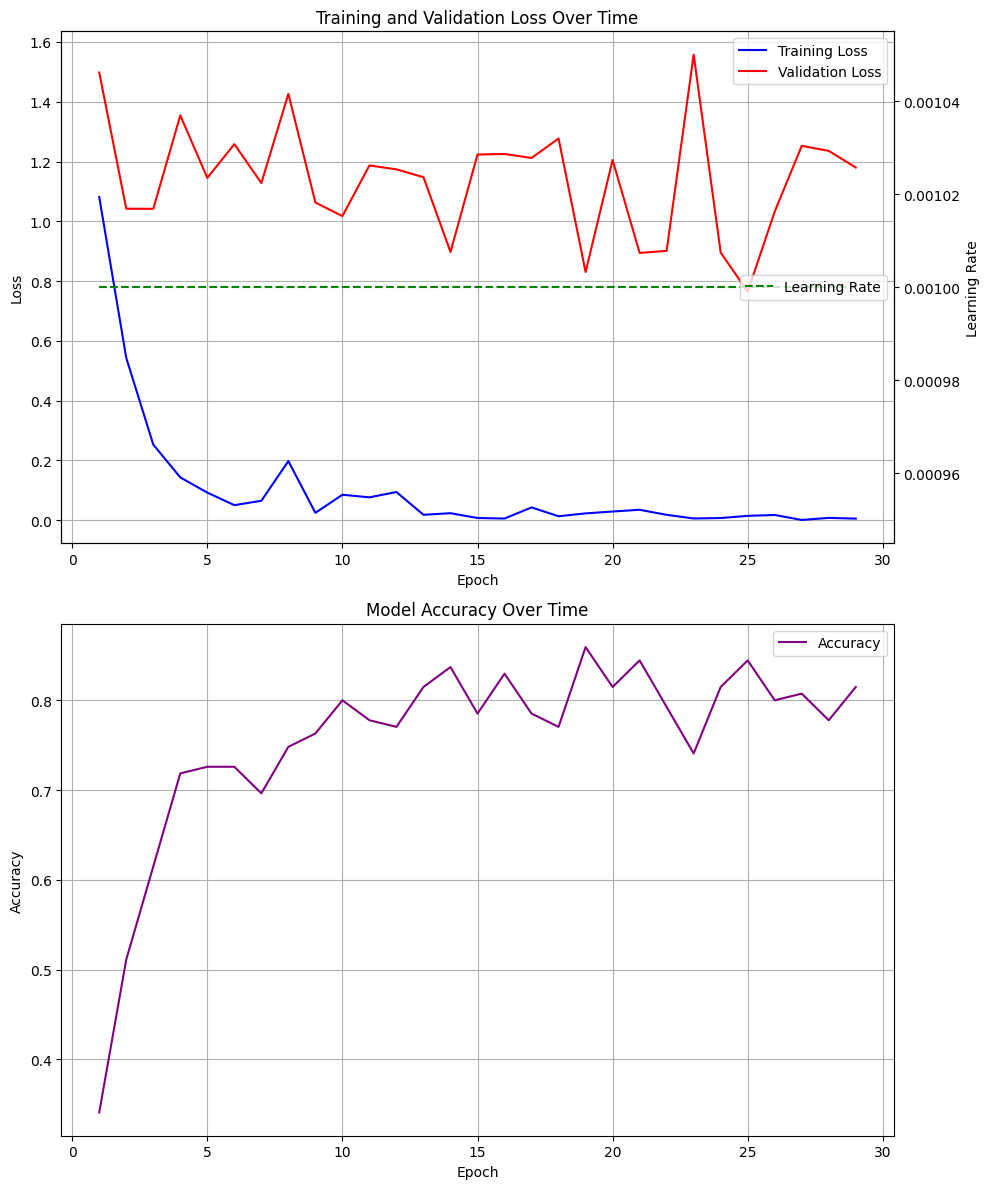

In [14]:
import matplotlib.pyplot as plt

# Create figure and axis objects with a single subplot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

# Get data from training history
epochs = [d['epoch'] for d in training_history]
train_loss = [d['train_loss'] for d in training_history]
val_loss = [d['val_loss'] for d in training_history]
accuracy = [d['acc'] for d in training_history]
learning_rates = [d['lr'] for d in training_history]

# Plot losses
ax1.plot(epochs, train_loss, 'b-', label='Training Loss')
ax1.plot(epochs, val_loss, 'r-', label='Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss Over Time')
ax1.legend()
ax1.grid(True)

# Create second y-axis for learning rate
ax1_twin = ax1.twinx()
ax1_twin.plot(epochs, learning_rates, 'g--', label='Learning Rate')
ax1_twin.set_ylabel('Learning Rate')
ax1_twin.legend(loc='center right')

# Plot accuracy
ax2.plot(epochs, accuracy, 'purple', label='Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Model Accuracy Over Time')
ax2.legend()
ax2.grid(True)

# Adjust layout to prevent overlap
plt.tight_layout()

plt.show()